# **1. Perkenalan Dataset**


## Dataset: Heart Disease Dataset

Dataset Heart Disease adalah dataset klasik yang digunakan untuk memprediksi apakah seseorang memiliki penyakit jantung berdasarkan berbagai fitur medis.

**Sumber:** Kaggle / UCI Machine Learning Repository

**Deskripsi:**
- **Jumlah sampel:** 303 baris
- **Jumlah fitur:** 13 fitur (campuran numerik dan kategorikal)
- **Target:** Binary classification (0 = tidak ada penyakit, 1 = ada penyakit)

**Fitur-fitur:**
1. `age` - Usia pasien
2. `sex` - Jenis kelamin (1=pria, 0=wanita)
3. `cp` - Tipe nyeri dada (0-3)
4. `trestbps` - Tekanan darah istirahat (mmHg)
5. `chol` - Kolesterol serum (mg/dl)
6. `fbs` - Gula darah puasa > 120 mg/dl (1=ya, 0=tidak)
7. `restecg` - Hasil elektrokardiografi istirahat (0-2)
8. `thalach` - Detak jantung maksimum
9. `exang` - Angina akibat olahraga (1=ya, 0=tidak)
10. `oldpeak` - Depresi ST akibat olahraga
11. `slope` - Kemiringan segmen ST puncak
12. `ca` - Jumlah pembuluh darah utama (0-3)
13. `thal` - Thalassemia (0-3)

**Target:** `target` - Diagnosis penyakit jantung (0=tidak ada, 1=ada)

**Alasan pemilihan dataset:**
Dataset ini dipilih karena relevan secara medis, memiliki campuran fitur numerik dan kategorikal yang menarik untuk dianalisis, dan cocok untuk demonstrasi pipeline ML end-to-end.

# **2. Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

print('Library berhasil diimport!')

Library berhasil diimport!


# **3. Memuat Dataset**

In [2]:
url = 'https://raw.githubusercontent.com/dsrscientist/dataset1/master/heartdisease.csv'

try:
    df = pd.read_csv(url)
    print('Dataset berhasil didownload dari URL!')
except:

    print('Download gagal, membuat dataset manual...')
    np.random.seed(42)
    n = 303
    df = pd.DataFrame({
        'age': np.random.randint(29, 77, n),
        'sex': np.random.randint(0, 2, n),
        'cp': np.random.randint(0, 4, n),
        'trestbps': np.random.randint(94, 200, n),
        'chol': np.random.randint(126, 564, n),
        'fbs': np.random.randint(0, 2, n),
        'restecg': np.random.randint(0, 3, n),
        'thalach': np.random.randint(71, 202, n),
        'exang': np.random.randint(0, 2, n),
        'oldpeak': np.round(np.random.uniform(0, 6.2, n), 1),
        'slope': np.random.randint(0, 3, n),
        'ca': np.random.randint(0, 4, n),
        'thal': np.random.randint(0, 4, n),
        'target': np.random.randint(0, 2, n)
    })

df.to_csv('heart.csv', index=False)
print(f'Shape: {df.shape}')
print(f'Kolom: {df.columns.tolist()}')
df.head()

Download gagal, membuat dataset manual...
Shape: (303, 14)
Kolom: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,67,1,2,126,458,1,2,154,1,5.4,2,0,1,0
1,57,0,0,158,384,0,1,76,0,1.0,0,3,2,1
2,43,0,3,111,286,0,2,201,1,4.9,1,3,3,0
3,71,1,2,189,515,1,1,71,1,3.6,0,0,1,0
4,36,0,0,142,303,0,2,128,1,3.5,0,3,0,1


# **4. Exploratory Data Analysis (EDA)**

In [3]:
print('='*50)
print('INFO DATASET')
print('='*50)
print(df.info())
print('\nSTATISTIK DESKRIPTIF:')
df.describe()

INFO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None

STATISTIK DESKRIPTIF:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.00000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,52.267327,0.544554,1.40264,146.511551,352.894389,0.471947,0.976898,135.491749,0.524752,3.020462,0.973597,1.462046,1.455446,0.495050
std,13.896179,0.498835,1.16925,31.336124,127.705381,0.500038,0.827584,39.067937,0.500213,1.774351,0.801052,1.167033,1.111571,0.500803
min,29.000000,0.000000,0.00000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,40.000000,0.000000,0.00000,119.000000,245.500000,0.000000,0.000000,102.000000,0.000000,1.400000,0.000000,0.000000,0.000000,0.000000
50%,53.000000,1.000000,1.00000,148.000000,354.000000,0.000000,1.000000,134.000000,1.000000,3.100000,1.000000,2.000000,1.000000,0.000000
75%,64.000000,1.000000,2.00000,174.000000,456.000000,1.000000,2.000000,168.500000,1.000000,4.600000,2.000000,3.000000,2.000000,1.000000
max,76.000000,1.000000,3.00000,199.000000,563.000000,1.000000,2.000000,201.000000,1.000000,6.200000,2.000000,3.000000,3.000000,1.000000


In [4]:
print('MISSING VALUES:')
print(df.isnull().sum())
print(f'\nTotal missing: {df.isnull().sum().sum()}')
print(f'Duplikat: {df.duplicated().sum()}')

MISSING VALUES:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total missing: 0
Duplikat: 0


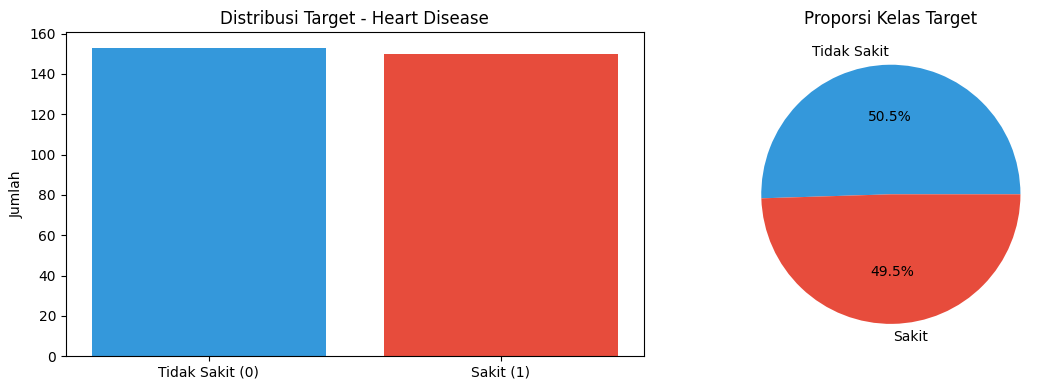

Distribusi target:
target
0    153
1    150
Name: count, dtype: int64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['target'].value_counts()
axes[0].bar(['Tidak Sakit (0)', 'Sakit (1)'], counts.values,
            color=['#3498db', '#e74c3c'])
axes[0].set_title('Distribusi Target - Heart Disease')
axes[0].set_ylabel('Jumlah')

axes[1].pie(counts.values, labels=['Tidak Sakit', 'Sakit'],
            autopct='%1.1f%%', colors=['#3498db', '#e74c3c'])
axes[1].set_title('Proporsi Kelas Target')

plt.tight_layout()
plt.savefig('eda_target.png', dpi=100)
plt.show()
print(f'Distribusi target:\n{counts}')

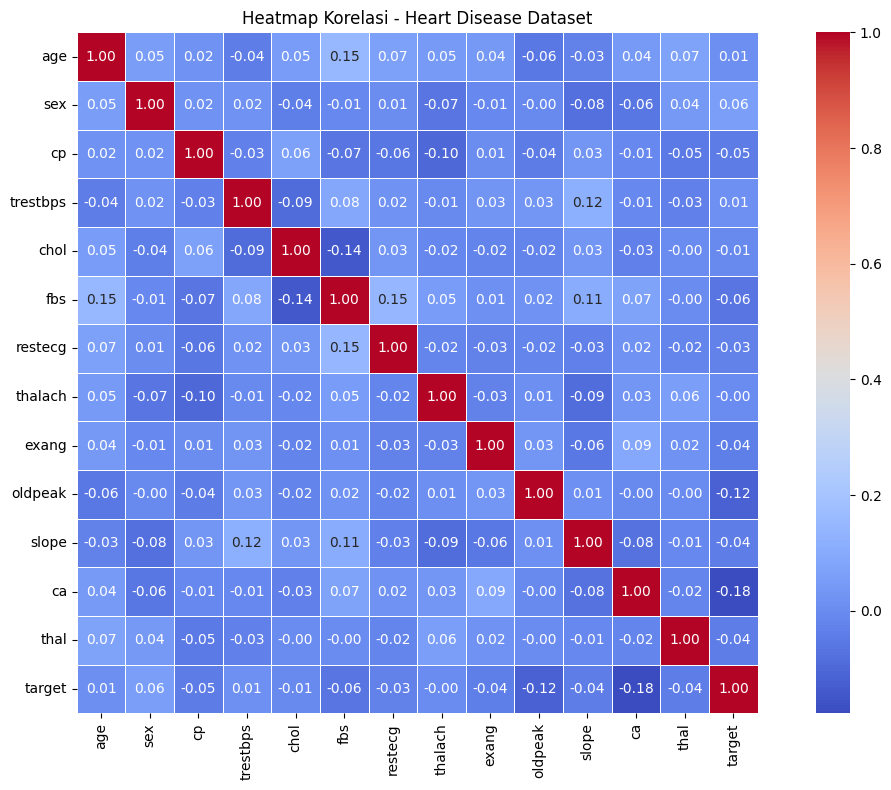

In [6]:
plt.figure(figsize=(12, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Heatmap Korelasi - Heart Disease Dataset')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=100)
plt.show()

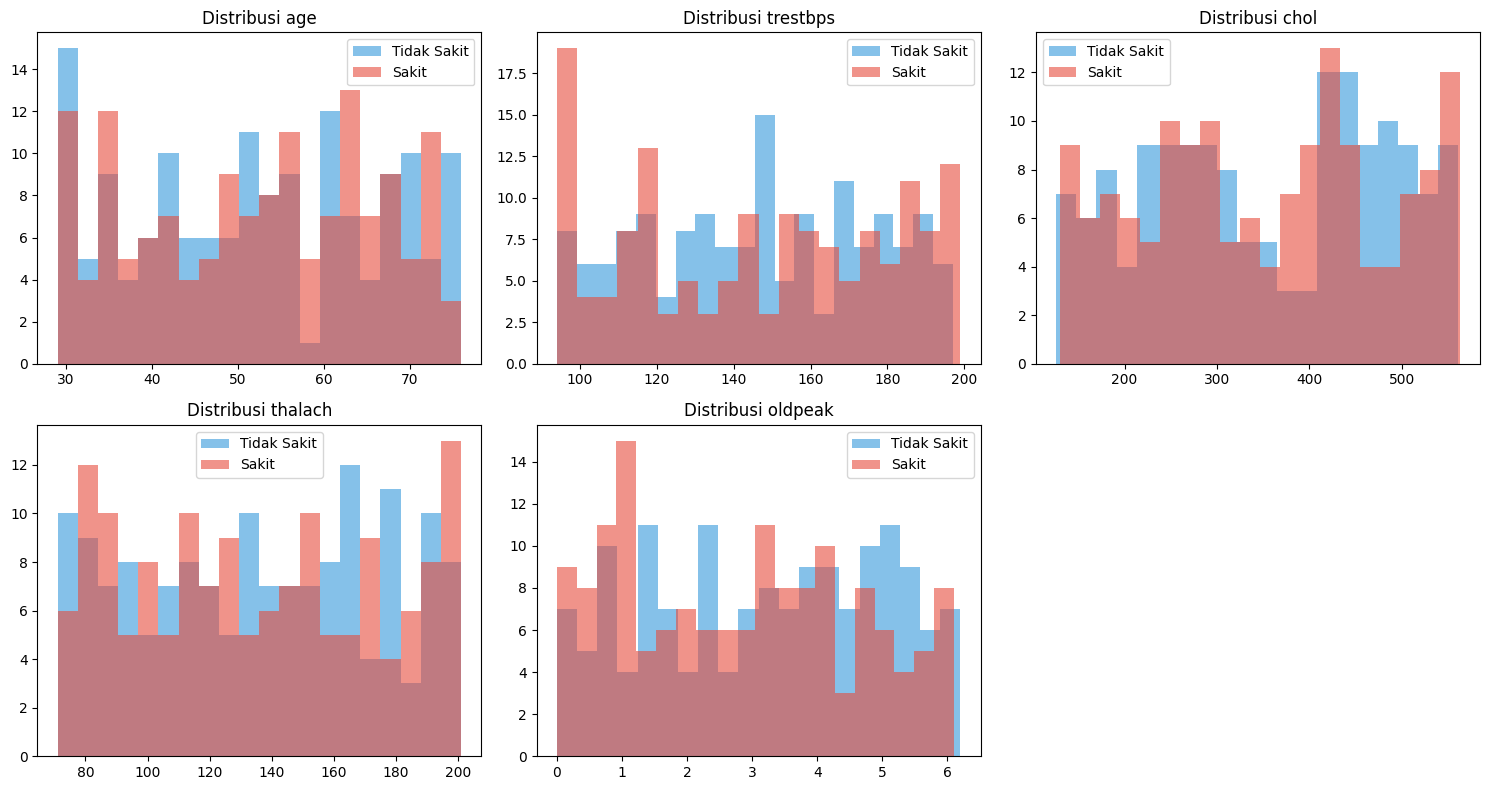

In [7]:
num_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(num_features):
    for target_val, color, label in [(0, '#3498db', 'Tidak Sakit'),
                                      (1, '#e74c3c', 'Sakit')]:
        axes[i].hist(df[df['target']==target_val][feat],
                     alpha=0.6, color=color, label=label, bins=20)
    axes[i].set_title(f'Distribusi {feat}')
    axes[i].legend()

axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('eda_features.png', dpi=100)
plt.show()

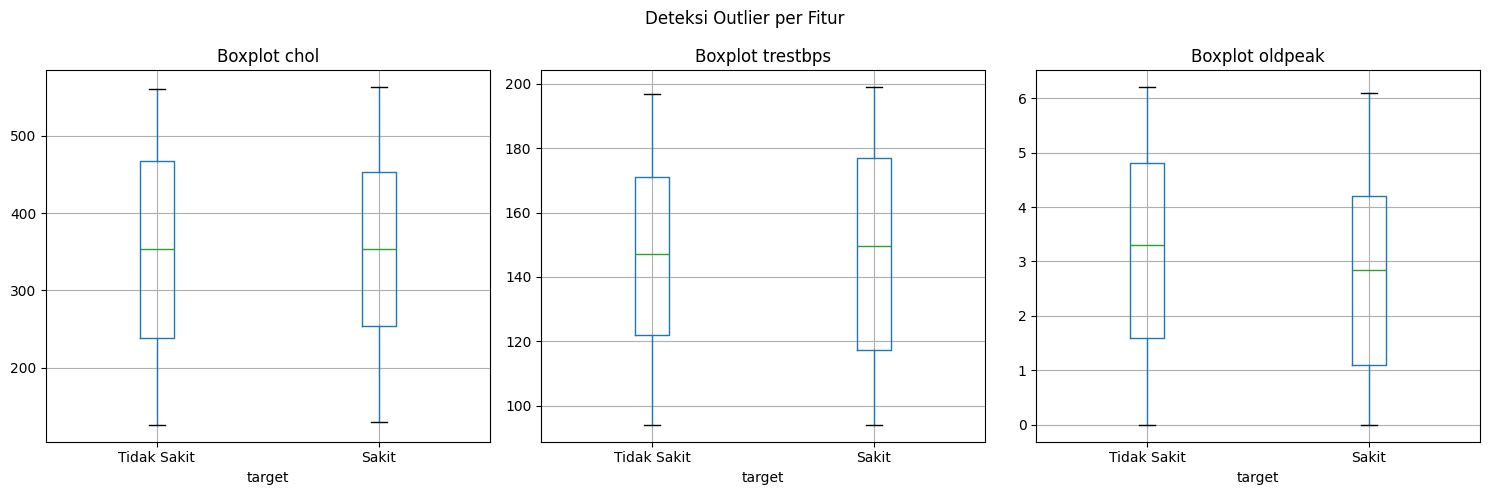


Kesimpulan EDA:
- Dataset relatif seimbang antara 2 kelas
- thalach (detak jantung max) berkorelasi negatif dengan target
- cp (tipe nyeri dada) berkorelasi positif dengan target
- Ada beberapa outlier pada kolom chol dan trestbps


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, feat in zip(axes, ['chol', 'trestbps', 'oldpeak']):
    df.boxplot(column=feat, by='target', ax=ax)
    ax.set_title(f'Boxplot {feat}')
    ax.set_xticklabels(['Tidak Sakit', 'Sakit'])

plt.suptitle('Deteksi Outlier per Fitur')
plt.tight_layout()
plt.savefig('eda_boxplot.png', dpi=100)
plt.show()

print('\nKesimpulan EDA:')
print('- Dataset relatif seimbang antara 2 kelas')
print('- thalach (detak jantung max) berkorelasi negatif dengan target')
print('- cp (tipe nyeri dada) berkorelasi positif dengan target')
print('- Ada beberapa outlier pada kolom chol dan trestbps')

# **5. Data Preprocessing**

In [9]:
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'Duplikat: {df.duplicated().sum()}')

df_clean = df.drop_duplicates().reset_index(drop=True)

num_cols = df_clean.select_dtypes(include=np.number).columns
imputer = SimpleImputer(strategy='median')
df_clean[num_cols] = imputer.fit_transform(df_clean[num_cols])

print(f'Shape setelah cleaning: {df_clean.shape}')

Missing values: 0
Duplikat: 0
Shape setelah cleaning: (303, 14)


In [10]:
X = df_clean.drop('target', axis=1)
y = df_clean['target']
print(f'Shape X: {X.shape}, Shape y: {y.shape}')

Shape X: (303, 13), Shape y: (303,)


In [11]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
print('Statistik setelah scaling:')
print(X_scaled.describe().round(3))

Statistik setelah scaling:
           age      sex       cp  trestbps     chol      fbs  restecg  \
count  303.000  303.000  303.000   303.000  303.000  303.000  303.000   
mean    -0.000   -0.000    0.000    -0.000   -0.000   -0.000   -0.000   
std      1.002    1.002    1.002     1.002    1.002    1.002    1.002   
min     -1.677   -1.093   -1.202    -1.679   -1.780   -0.945   -1.182   
25%     -0.884   -1.093   -1.202    -0.879   -0.842   -0.945   -1.182   
50%      0.053    0.915   -0.345     0.048    0.009   -0.945    0.028   
75%      0.846    0.915    0.512     0.879    0.809    1.058    1.238   
max      1.711    0.915    1.368     1.678    1.648    1.058    1.238   

       thalach    exang  oldpeak    slope       ca     thal  
count  303.000  303.000  303.000  303.000  303.000  303.000  
mean     0.000   -0.000   -0.000   -0.000   -0.000    0.000  
std      1.002    1.002    1.002    1.002    1.002    1.002  
min     -1.653   -1.051   -1.705   -1.217   -1.255   -1.312  
25%  

In [12]:
import os
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')

os.makedirs('nadataset_preprocessing', exist_ok=True)
X_train.to_csv('nadataset_preprocessing/X_train.csv', index=False)
X_test.to_csv('nadataset_preprocessing/X_test.csv', index=False)
y_train.to_csv('nadataset_preprocessing/y_train.csv', index=False)
y_test.to_csv('nadataset_preprocessing/y_test.csv', index=False)

print('Preprocessing selesai!')
print(f'Files: {os.listdir("nadataset_preprocessing")}')

X_train: (242, 13), X_test: (61, 13)
Preprocessing selesai!
Files: ['y_train.csv', 'X_test.csv', 'X_train.csv', 'y_test.csv']
